# Excel Loader Diagnostics

This notebook loads `cleaned_project_risk_dataset_UPDATED.xlsx`, prints every activity and risk row, and checks that the simulator objects use the same min/max/most-likely parameters as the workbook.

In [2]:
from pathlib import Path
import sys

for folder in [Path.cwd(), *Path.cwd().parents]:
    src = folder / "src"
    if (src / "spm").exists():
        sys.path.insert(0, str(src))
        break
else:
    raise ModuleNotFoundError("Could not find local src/spm package. Launch Jupyter inside the SPM repo or run pip install -e .")

from spm.distributions import DeterministicContinuousDistribution, DiscreteUniformDuration, PERTDistribution, ShiftedBinomialDuration, UniformContinuousDistribution
from spm.interfaces import excel_project_summary, load_project_from_excel, read_excel_tables

workbook = Path("cleaned_project_risk_dataset_UPDATED.xlsx")
if not workbook.exists():
    workbook = Path("Time and Cost experiment/Experiment/cleaned_project_risk_dataset_UPDATED.xlsx")

print(workbook.resolve())
tables = read_excel_tables(workbook)
imported = load_project_from_excel(workbook, sample_count=5_000_000, rng_seed=2026)
project = imported.simulator_project

print(excel_project_summary(imported))

C:\Users\johan\OneDrive\Skrivbord\SPM\Time and Cost experiment\Experiment\cleaned_project_risk_dataset_UPDATED.xlsx
Project: cleaned_project_risk_dataset_UPDATED
Activities: 32
Risks: 15

id | predecessors | schedule risks | cost risks | E[D_i]
----------------------------------------------------------------
A1 | empty | - | - | 15.0
A2 | A1 | R2 | R10 | 30.0
A3 | A1 | - | - | 30.0
A7 | A1 | - | - | 70.0
A16 | A1 | - | - | 190.0
A5 | A2 | - | - | 70.0
A6 | A2 | R1 | - | 90.0
A17 | A2 | - | - | 55.0
A4 | A2, A3 | - | - | 55.0
A19 | A3 | - | - | 55.0
A11 | A7 | - | - | 80.0
A12 | A7 | R4 | - | 110.0
A13 | A7 | R3 | R12 | 80.0
A8 | A5 | - | R11 | 25.0
A9 | A5 | - | - | 85.0
A10 | A6 | - | - | 85.0
A18 | A17 | - | - | 60.0
A20 | A3, A4 | R5 | - | 95.0
A14 | A11, A13 | - | - | 30.0
A25 | A8 | - | - | 45.0
A21 | A18 | - | - | 25.0
A23 | A18 | R9 | - | 40.0
A29 | A12, A20 | - | - | 15.0
A15 | A14 | - | - | 15.0
A22 | A21 | - | - | 20.0
A24 | A21 | - | - | 40.0
A26 | A21, A25 | R6 | R13 | 85.0

In [3]:
def model_bounds(model):
    if isinstance(model, DeterministicContinuousDistribution):
        return (model.value, model.value, model.value)
    if isinstance(model, PERTDistribution):
        return (model.minimum, model.most_likely, model.maximum)
    if isinstance(model, UniformContinuousDistribution):
        return (model.minimum, None, model.maximum)
    if isinstance(model, ShiftedBinomialDuration):
        return (model.minimum, model.most_likely, model.maximum)
    if isinstance(model, DiscreteUniformDuration):
        return (model.minimum, None, model.maximum)
    return (None, None, None)

def activity_number(activity_id):
    return int(str(activity_id).replace("A", ""))

activity_rows = tables["Activities"]
risk_rows = tables["Risks"]

assert len(activity_rows) == 32, len(activity_rows)
assert len(risk_rows) == 15, len(risk_rows)
assert len(project.work_packages) == len(activity_rows)
assert len(imported.risks) == len(risk_rows)

print("Workbook and Project counts are consistent.")

Workbook and Project counts are consistent.


In [4]:
print("ACTIVITY DIAGNOSTICS")
print("=" * 120)

for row in activity_rows:
    node = activity_number(row["Activity_ID"])
    wp = project.work_packages[node]
    duration = wp.duration_model
    daily = wp.daily_cost_model
    fixed = wp.fixed_costs[0]
    predecessors = list(project.graph.predecessors(node))
    lags = [project.graph.edges[pred, node]["lag_model"].lag for pred in predecessors]

    assert isinstance(duration, ShiftedBinomialDuration)
    assert duration.minimum == int(row["Duration_Min_Days"])
    assert duration.most_likely == int(row["Duration_Most_Likely_Days"])
    assert duration.maximum == int(row["Duration_Max_Days"])

    fixed_min, fixed_mode, fixed_max = model_bounds(fixed)
    daily_min, daily_mode, daily_max = model_bounds(daily)
    assert fixed_min == float(row["Cost_Min_x1000"])
    assert fixed_mode == float(row["Cost_Most_Likely_x1000"])
    assert fixed_max == float(row["Cost_Max_x1000"])
    assert daily_min == float(row["Variable_Cost_Min_x1000"])
    assert daily_mode == float(row["Variable_Cost_per_x1000"])
    assert daily_max == float(row["Variable_Cost_Max_Days_x1000"])

    print(
        f"{row['Activity_ID']:>3} | pred={row['Predecessors']!r} -> {predecessors} | lag={lags or [0]} | "
        f"duration {type(duration).__name__}(min={duration.minimum}, most={duration.most_likely}, max={duration.maximum}, E={duration.expected_value:.3f}) | "
        f"fixed {type(fixed).__name__}(min={fixed_min}, most={fixed_mode}, max={fixed_max}, E={fixed.expected_value:.3f}) | "
        f"daily {type(daily).__name__}(min={daily_min}, most={daily_mode}, max={daily_max}, E={daily.expected_value:.3f}) | "
        f"schedule_risks={len(wp.schedule_risks)} cost_risks={len(wp.cost_risks)}"
    )

print("\nAll activity parameter checks passed.")

ACTIVITY DIAGNOSTICS
 A1 | pred='Ai' -> [] | lag=[0] | duration ShiftedBinomialDuration(min=10, most=15, max=20, E=15.000) | fixed DeterministicContinuousDistribution(min=0.0, most=0.0, max=0.0, E=0.000) | daily PERTDistribution(min=0.75, most=1.0, max=1.25, E=1.000) | schedule_risks=0 cost_risks=0
 A2 | pred='A1' -> [1] | lag=[0] | duration ShiftedBinomialDuration(min=25, most=30, max=35, E=30.000) | fixed DeterministicContinuousDistribution(min=0.0, most=0.0, max=0.0, E=0.000) | daily PERTDistribution(min=1.875, most=2.5, max=3.125, E=2.500) | schedule_risks=1 cost_risks=1
 A3 | pred='A1' -> [1] | lag=[0] | duration ShiftedBinomialDuration(min=20, most=30, max=40, E=30.000) | fixed DeterministicContinuousDistribution(min=0.0, most=0.0, max=0.0, E=0.000) | daily PERTDistribution(min=3.375, most=4.5, max=5.625, E=4.500) | schedule_risks=0 cost_risks=0
 A4 | pred='A2, A3' -> [2, 3] | lag=[0, 0] | duration ShiftedBinomialDuration(min=45, most=55, max=65, E=55.000) | fixed DeterministicCo

In [5]:
print("RISK DIAGNOSTICS")
print("=" * 120)

schedule_seen = {}
cost_seen = {}

for row in risk_rows:
    risk_id = row["Risk_ID"]
    node = activity_number(row["Affected_Activity_ID"])
    wp = project.work_packages[node]
    risk_type = row["Risk_Type"]

    if risk_type == "Schedule":
        index = schedule_seen.get(node, 0)
        loaded = wp.schedule_risks[index]
        schedule_seen[node] = index + 1
        impact = loaded.severity_model
        assert isinstance(impact, DiscreteUniformDuration)
        assert impact.minimum == int(row["Impact_Min"])
        assert impact.maximum == int(row["Impact_Max"])
    else:
        index = cost_seen.get(node, 0)
        loaded = wp.cost_risks[index]
        cost_seen[node] = index + 1
        impact = loaded.severity_model
        assert isinstance(impact, UniformContinuousDistribution)
        assert impact.minimum == float(row["Impact_Min"])
        assert impact.maximum == float(row["Impact_Max"])

    probability = loaded.probability_model
    assert isinstance(probability, UniformContinuousDistribution)
    assert probability.minimum == float(row["Probability_Min"])
    assert probability.maximum == float(row["Probability_Max"])

    print(
        f"{risk_id:>3} | {risk_type:<8} | activity={row['Affected_Activity_ID']} | "
        f"P={type(probability).__name__}(min={probability.minimum}, max={probability.maximum}, E={probability.expected_value:.4f}) | "
        f"impact={type(impact).__name__}(min={impact.minimum}, max={impact.maximum}, E={impact.expected_value:.3f}) | "
        f"units={row['Impact_Units']} | name={row['Source_Risk_Name']}"
    )

print("\nAll risk parameter checks passed.")

RISK DIAGNOSTICS
 R1 | Schedule | activity=A6 | P=UniformContinuousDistribution(min=0.0, max=0.03, E=0.0150) | impact=DiscreteUniformDuration(min=5, max=20, E=12.500) | units=days | name=Technical complexity of the engineering project
 R2 | Schedule | activity=A2 | P=UniformContinuousDistribution(min=0.3, max=0.5, E=0.4000) | impact=DiscreteUniformDuration(min=20, max=50, E=35.000) | units=days | name=Change of requirements in the project
 R3 | Schedule | activity=A13 | P=UniformContinuousDistribution(min=0.03, max=0.1, E=0.0650) | impact=DiscreteUniformDuration(min=50, max=75, E=62.500) | units=days | name=Supply chain disruptions
 R4 | Schedule | activity=A12 | P=UniformContinuousDistribution(min=0.1, max=0.3, E=0.2000) | impact=DiscreteUniformDuration(min=5, max=20, E=12.500) | units=days | name=Inaccurate internal needs analysis
 R5 | Schedule | activity=A20 | P=UniformContinuousDistribution(min=0.1, max=0.3, E=0.2000) | impact=DiscreteUniformDuration(min=20, max=50, E=35.000) | un

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def expected_value(model):
    value = getattr(model, "expected_value", None)
    if value is None:
        return np.nan
    if callable(value):
        value = value()
    return float(value)


def safe_z_score(observed, expected, se):
    if se == 0 or not np.isfinite(se):
        return 0.0 if np.isclose(observed, expected) else np.inf
    return (observed - expected) / se


def get_loaded_risk_objects(project, risk_rows):
    """
    Reconstruct the same risk order used by the Excel loader:
    risks are appended to each activity in the order they appear in the Risks sheet.
    """
    loaded_rows = []
    schedule_seen = {}
    cost_seen = {}

    for row in risk_rows:
        risk_id = row["Risk_ID"]
        risk_type = row["Risk_Type"]
        node = activity_number(row["Affected_Activity_ID"])
        wp = project.work_packages[node]

        if risk_type == "Schedule":
            idx = schedule_seen.get(node, 0)
            risk = wp.schedule_risks[idx]
            schedule_seen[node] = idx + 1
        elif risk_type == "Cost":
            idx = cost_seen.get(node, 0)
            risk = wp.cost_risks[idx]
            cost_seen[node] = idx + 1
        else:
            raise ValueError(f"Unknown risk type: {risk_type}")

        loaded_rows.append(
            {
                "Risk_ID": risk_id,
                "Risk_Type": risk_type,
                "Activity": f"A{node}",
                "Node": node,
                "Risk_Index_Within_Activity": idx,
                "Risk_Object": risk,
                "Raw_Row": row,
            }
        )

    return loaded_rows


loaded_risks = get_loaded_risk_objects(project, risk_rows)

print(f"Loaded risk objects: {len(loaded_risks)}")
print(f"Schedule risks loaded: {sum(r['Risk_Type'] == 'Schedule' for r in loaded_risks)}")
print(f"Cost risks loaded: {sum(r['Risk_Type'] == 'Cost' for r in loaded_risks)}")

Loaded risk objects: 15
Schedule risks loaded: 9
Cost risks loaded: 6


In [7]:
RISK_DIAG_SAMPLE_COUNT = 5_000_000
rng = np.random.default_rng(987654)

risk_diag_rows = []

for item in loaded_risks:
    risk_id = item["Risk_ID"]
    risk_type = item["Risk_Type"]
    activity = item["Activity"]
    risk = item["Risk_Object"]

    result = risk.simulate(RISK_DIAG_SAMPLE_COUNT, rng)

    probabilities = np.asarray(result.probabilities, dtype=float)
    severities = np.asarray(result.severities)
    occurrences = np.asarray(result.occurrences, dtype=bool)
    effects = np.asarray(result.effects)

    expected_p = expected_value(risk.probability_model)
    expected_u = expected_value(risk.severity_model)
    expected_effect = expected_p * expected_u

    empirical_p_mean = probabilities.mean()
    empirical_u_mean = severities.mean()
    empirical_occurrence_rate = occurrences.mean()
    empirical_effect_mean = effects.mean()

    occurrence_residual = occurrences.astype(float) - probabilities
    occurrence_residual_mean = occurrence_residual.mean()
    occurrence_residual_se = occurrence_residual.std(ddof=1) / np.sqrt(RISK_DIAG_SAMPLE_COUNT)
    occurrence_residual_z = safe_z_score(
        occurrence_residual_mean,
        0.0,
        occurrence_residual_se,
    )

    effect_se = effects.std(ddof=1) / np.sqrt(RISK_DIAG_SAMPLE_COUNT)
    effect_z = safe_z_score(
        empirical_effect_mean,
        expected_effect,
        effect_se,
    )

    if risk_type == "Schedule":
        reconstructed_effects = occurrences.astype(np.uint32) * severities.astype(np.uint32)
    else:
        reconstructed_effects = occurrences.astype(float) * severities.astype(float)

    effect_identity_ok = np.allclose(effects, reconstructed_effects)

    p_min, p_mode, p_max = model_bounds(risk.probability_model)
    u_min, u_mode, u_max = model_bounds(risk.severity_model)

    probability_support_ok = (
        np.all(np.isfinite(probabilities))
        and np.all(probabilities >= p_min)
        and np.all(probabilities <= p_max)
    )

    severity_support_ok = (
        np.all(np.isfinite(severities))
        and np.all(severities >= u_min)
        and np.all(severities <= u_max)
    )

    risk_diag_rows.append(
        {
            "Risk_ID": risk_id,
            "Type": risk_type,
            "Activity": activity,
            "E[P]": expected_p,
            "mean(P)": empirical_p_mean,
            "occurrence_rate": empirical_occurrence_rate,
            "mean(occurrence - P)": occurrence_residual_mean,
            "z_occurrence_minus_P": occurrence_residual_z,
            "E[U]": expected_u,
            "mean(U)": empirical_u_mean,
            "E[R]": expected_effect,
            "mean(R)": empirical_effect_mean,
            "SE(mean R)": effect_se,
            "z_mean_R": effect_z,
            "effect=occurrence*severity": effect_identity_ok,
            "P support ok": probability_support_ok,
            "U support ok": severity_support_ok,
        }
    )

risk_diag_df = pd.DataFrame(risk_diag_rows)

display(
    risk_diag_df[
        [
            "Risk_ID",
            "Type",
            "Activity",
            "E[P]",
            "mean(P)",
            "occurrence_rate",
            "mean(occurrence - P)",
            "z_occurrence_minus_P",
            "E[U]",
            "mean(U)",
            "E[R]",
            "mean(R)",
            "SE(mean R)",
            "z_mean_R",
            "effect=occurrence*severity",
            "P support ok",
            "U support ok",
        ]
    ]
)

bad_rows = risk_diag_df[
    (~risk_diag_df["effect=occurrence*severity"])
    | (~risk_diag_df["P support ok"])
    | (~risk_diag_df["U support ok"])
    | (risk_diag_df["z_occurrence_minus_P"].abs() > 5)
    | (risk_diag_df["z_mean_R"].abs() > 5)
]

if len(bad_rows) > 0:
    display(bad_rows)
    raise AssertionError("At least one risk simulation diagnostic failed.")

print("All direct risk simulation diagnostics passed.")

,Risk_ID,Type,Activity,E[P],mean(P),occurrence_rate,mean(occurrence - P),z_occurrence_minus_P,E[U],mean(U),E[R],mean(R),SE(mean R),z_mean_R,effect=occurrence*severity,P support ok,U support ok
0,R1,Schedule,A6,0.015,0.014992,0.015016,0.000025,0.454726,12.5,12.501141,0.1875,0.187699,0.000725,0.273874,True,True,True
1,R2,Schedule,A2,0.400,0.400018,0.399877,-0.000140,-0.645135,35.0,35.001362,14.0000,13.997168,0.008075,-0.350769,True,True,True
2,R3,Schedule,A13,0.065,0.065008,0.064822,-0.000186,-1.694471,62.5,62.501302,4.0625,4.051129,0.006934,-1.639836,True,True,True
3,R4,Schedule,A12,0.200,0.199983,0.200012,0.000029,0.163429,12.5,12.498627,2.5000,2.499525,0.002418,-0.196254,True,True,True
4,R5,Schedule,A20,0.200,0.200030,0.199988,-0.000043,-0.242042,35.0,35.005002,7.0000,6.999431,0.006511,-0.087323,True,True,True
5,R6,Schedule,A26,0.065,0.065005,0.065029,0.000024,0.221485,12.5,12.502173,0.8125,0.812973,0.001475,0.320713,True,True,True
6,R7,Schedule,A30,0.015,0.015005,0.014972,-0.000033,-0.609049,35.0,35.002383,0.5250,0.523328,0.001961,-0.852930,True,True,True
7,R8,Schedule,A28,0.200,0.200033,0.200151,0.000119,0.669690,35.0,35.007166,7.0000,7.004155,0.006513,0.637966,True,True,True
8,R9,Schedule,A23,0.065,0.065005,0.065052,0.000047,0.424775,12.5,12.498830,0.8125,0.812023,0.001474,-0.323764,True,True,True
9,R10,Cost,A2,0.400,0.399973,0.399869,-0.000104,-0.480238,425.0,424.899564,170.0000,169.929521,0.107161,-0.657691,True,True,True


All direct risk simulation diagnostics passed.


In [8]:
# Make sure the active project has simulated durations, critical activities, and costs.
# If you already ran this above, this will just overwrite with a fresh simulation.
time_result = project.simulate_project_time_with_critical_activities()
project.simulate_all_costs()

assembly_rows = []

for node, wp in sorted(project.work_packages.items()):
    activity = f"A{node}"

    assert wp.baseline_duration_samples is not None
    assert wp.duration_samples is not None
    assert wp.schedule_risk_total_samples is not None
    assert wp.baseline_cost_samples is not None
    assert wp.cost_samples is not None
    assert wp.cost_risk_total_samples is not None

    reconstructed_duration = (
        wp.baseline_duration_samples.astype(np.uint64)
        + wp.schedule_risk_total_samples.astype(np.uint64)
    )

    duration_ok = np.array_equal(
        wp.duration_samples.astype(np.uint64),
        reconstructed_duration,
    )

    reconstructed_cost = (
        wp.baseline_cost_samples.astype(float)
        + wp.cost_risk_total_samples.astype(float)
    )

    cost_ok = np.allclose(
        wp.cost_samples.astype(float),
        reconstructed_cost,
    )

    schedule_sum_from_results = np.zeros_like(wp.schedule_risk_total_samples, dtype=np.uint64)
    for result in wp.schedule_risk_results:
        schedule_sum_from_results += result.effects.astype(np.uint64)

    schedule_total_ok = np.array_equal(
        wp.schedule_risk_total_samples.astype(np.uint64),
        schedule_sum_from_results,
    )

    cost_sum_from_results = np.zeros_like(wp.cost_risk_total_samples, dtype=float)
    for result in wp.cost_risk_results:
        cost_sum_from_results += result.effects.astype(float)

    cost_total_ok = np.allclose(
        wp.cost_risk_total_samples.astype(float),
        cost_sum_from_results,
    )

    expected_duration_ok = np.isclose(
        wp.expected_duration,
        wp.expected_baseline_duration + wp.expected_schedule_risk_total,
    )

    expected_cost_ok = np.isclose(
        wp.expected_total_cost,
        wp.expected_baseline_cost + wp.expected_cost_risk_total,
    )

    assembly_rows.append(
        {
            "Activity": activity,
            "schedule_risks": len(wp.schedule_risks),
            "cost_risks": len(wp.cost_risks),
            "mean_baseline_duration": wp.baseline_duration_samples.mean(),
            "mean_schedule_risk_total": wp.schedule_risk_total_samples.mean(),
            "mean_total_duration": wp.duration_samples.mean(),
            "expected_baseline_duration": wp.expected_baseline_duration,
            "expected_schedule_risk_total": wp.expected_schedule_risk_total,
            "expected_total_duration": wp.expected_duration,
            "duration = baseline + schedule risks": duration_ok,
            "schedule total = sum individual schedule risks": schedule_total_ok,
            "mean_baseline_cost": wp.baseline_cost_samples.mean(),
            "mean_cost_risk_total": wp.cost_risk_total_samples.mean(),
            "mean_total_cost": wp.cost_samples.mean(),
            "expected_baseline_cost": wp.expected_baseline_cost,
            "expected_cost_risk_total": wp.expected_cost_risk_total,
            "expected_total_cost": wp.expected_total_cost,
            "cost = baseline + cost risks": cost_ok,
            "cost total = sum individual cost risks": cost_total_ok,
            "expected duration assembly ok": expected_duration_ok,
            "expected cost assembly ok": expected_cost_ok,
        }
    )

assembly_df = pd.DataFrame(assembly_rows)

display(assembly_df)

bad_assembly = assembly_df[
    (~assembly_df["duration = baseline + schedule risks"])
    | (~assembly_df["schedule total = sum individual schedule risks"])
    | (~assembly_df["cost = baseline + cost risks"])
    | (~assembly_df["cost total = sum individual cost risks"])
    | (~assembly_df["expected duration assembly ok"])
    | (~assembly_df["expected cost assembly ok"])
]

if len(bad_assembly) > 0:
    display(bad_assembly)
    raise AssertionError("At least one work-package assembly diagnostic failed.")

print("All work-package risk assembly diagnostics passed.")

,Activity,schedule_risks,cost_risks,mean_baseline_duration,mean_schedule_risk_total,mean_total_duration,expected_baseline_duration,expected_schedule_risk_total,expected_total_duration,duration = baseline + schedule risks,...,mean_baseline_cost,mean_cost_risk_total,mean_total_cost,expected_baseline_cost,expected_cost_risk_total,expected_total_cost,cost = baseline + cost risks,cost total = sum individual cost risks,expected duration assembly ok,expected cost assembly ok
0,A1,0,0,14.999090,0.000000,14.999090,15.0,0.0000,15.0000,True,...,14.999570,0.000000,14.999570,15.00000,0.000,15.00000,True,True,True,True
1,A2,1,1,30.000128,14.005082,44.005210,30.0,14.0000,44.0000,True,...,110.001463,169.922901,279.924364,110.00000,170.000,280.00000,True,True,True,True
2,A3,0,0,30.002296,0.000000,30.002296,30.0,0.0000,30.0000,True,...,135.009166,0.000000,135.009166,135.00000,0.000,135.00000,True,True,True,True
3,A4,0,0,54.998982,0.000000,54.998982,55.0,0.0000,55.0000,True,...,247.481628,0.000000,247.481628,247.50000,0.000,247.50000,True,True,True,True
4,A5,0,0,70.000195,0.000000,70.000195,70.0,0.0000,70.0000,True,...,525.037228,0.000000,525.037228,525.00000,0.000,525.00000,True,True,True,True
5,A6,1,0,90.000269,0.188226,90.188495,90.0,0.1875,90.1875,True,...,315.677973,0.000000,315.677973,315.65625,0.000,315.65625,True,True,True,True
6,A7,0,0,70.001424,0.000000,70.001424,70.0,0.0000,70.0000,True,...,700.023181,0.000000,700.023181,700.00000,0.000,700.00000,True,True,True,True
7,A8,0,1,24.999385,0.000000,24.999385,25.0,0.0000,25.0000,True,...,650.506450,106.008705,756.515155,650.50000,105.625,756.12500,True,True,True,True
8,A9,0,0,84.998616,0.000000,84.998616,85.0,0.0000,85.0000,True,...,4200.004944,0.000000,4200.004944,4200.00000,0.000,4200.00000,True,True,True,True
9,A10,0,0,85.001374,0.000000,85.001374,85.0,0.0000,85.0000,True,...,3675.212983,0.000000,3675.212983,3675.00000,0.000,3675.00000,True,True,True,True


All work-package risk assembly diagnostics passed.


In [9]:
stored_risk_rows = []

schedule_seen = {}
cost_seen = {}

for item in loaded_risks:
    risk_id = item["Risk_ID"]
    risk_type = item["Risk_Type"]
    node = item["Node"]
    wp = project.work_packages[node]

    if risk_type == "Schedule":
        idx = schedule_seen.get(node, 0)
        result = wp.schedule_risk_results[idx]
        schedule_seen[node] = idx + 1
        units = "days"
    else:
        idx = cost_seen.get(node, 0)
        result = wp.cost_risk_results[idx]
        cost_seen[node] = idx + 1
        units = "x1000 monetary units"

    stored_risk_rows.append(
        {
            "Risk_ID": risk_id,
            "Type": risk_type,
            "Activity": f"A{node}",
            "Units": units,
            "mean(P)": result.probabilities.mean(),
            "occurrence_rate": result.occurrences.mean(),
            "mean(severity)": result.severities.mean(),
            "mean(effect)": result.effects.mean(),
            "p50(effect)": np.quantile(result.effects, 0.50),
            "p90(effect)": np.quantile(result.effects, 0.90),
            "p95(effect)": np.quantile(result.effects, 0.95),
            "max(effect)": result.effects.max(),
            "expected_effect_stored": result.expected_effect,
            "abs(mean - expected)": abs(result.effects.mean() - result.expected_effect),
        }
    )

stored_risk_df = pd.DataFrame(stored_risk_rows)

display(stored_risk_df)

,Risk_ID,Type,Activity,Units,mean(P),occurrence_rate,mean(severity),mean(effect),p50(effect),p90(effect),p95(effect),max(effect),expected_effect_stored,abs(mean - expected)
0,R1,Schedule,A6,days,0.015002,0.015041,12.502024,0.188226,0.0,0.000000,0.000000,20.000000,0.1875,0.000726
1,R2,Schedule,A2,days,0.400007,0.400113,34.997989,14.005082,0.0,43.000000,47.000000,50.000000,14.0000,0.005082
2,R3,Schedule,A13,days,0.064997,0.064809,62.497302,4.050389,0.0,0.000000,55.000000,75.000000,4.0625,0.012111
3,R4,Schedule,A12,days,0.199993,0.200164,12.496737,2.501407,0.0,12.000000,16.000000,20.000000,2.5000,0.001407
4,R5,Schedule,A20,days,0.200009,0.199647,35.000213,6.987626,0.0,35.000000,43.000000,50.000000,7.0000,0.012374
5,R6,Schedule,A26,days,0.065008,0.064990,12.500528,0.812193,0.0,0.000000,8.000000,20.000000,0.8125,0.000307
6,R7,Schedule,A30,days,0.014999,0.014990,34.998998,0.525300,0.0,0.000000,0.000000,50.000000,0.5250,0.000300
7,R8,Schedule,A28,days,0.200031,0.200080,34.997404,7.001861,0.0,35.000000,43.000000,50.000000,7.0000,0.001861
8,R9,Schedule,A23,days,0.064989,0.064946,12.500168,0.811939,0.0,0.000000,8.000000,20.000000,0.8125,0.000561
9,R10,Cost,A2,x1000 monetary units,0.399959,0.399679,425.102697,169.922901,0.0,587.536513,668.893837,749.999020,170.0000,0.077099


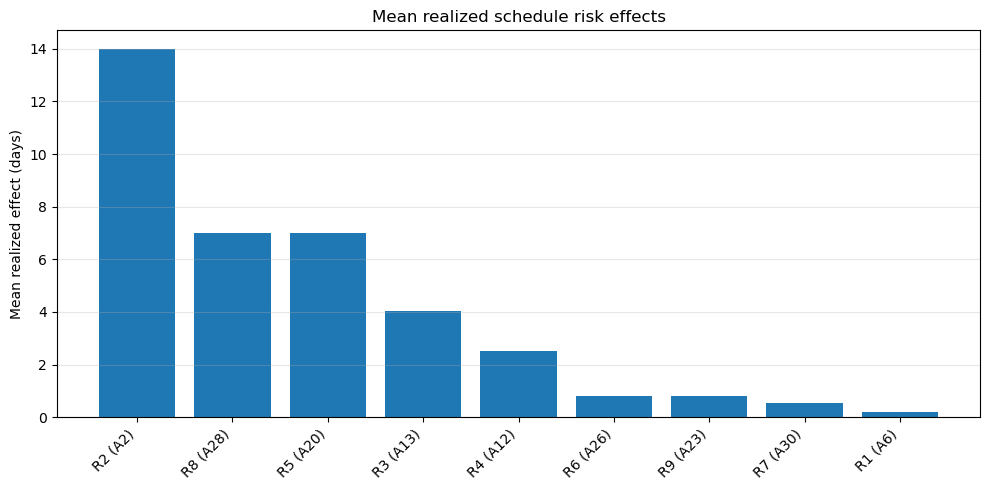

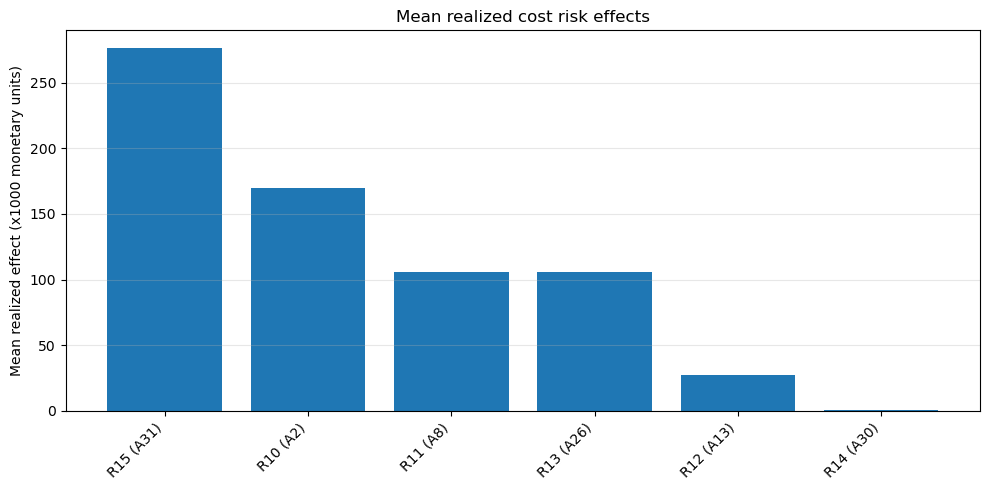

In [10]:
plot_df = stored_risk_df.copy()
plot_df["Risk_Label"] = plot_df["Risk_ID"] + " (" + plot_df["Activity"] + ")"

for risk_type in ["Schedule", "Cost"]:
    subset = plot_df[plot_df["Type"] == risk_type].copy()

    if len(subset) == 0:
        continue

    subset = subset.sort_values("mean(effect)", ascending=False)

    plt.figure(figsize=(10, 5))
    plt.bar(subset["Risk_Label"], subset["mean(effect)"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(f"Mean realized effect ({subset['Units'].iloc[0]})")
    plt.title(f"Mean realized {risk_type.lower()} risk effects")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

In [11]:
risk_effect_presence_rows = []

for node, wp in sorted(project.work_packages.items()):
    activity = f"A{node}"

    has_schedule_risk = len(wp.schedule_risks) > 0
    has_cost_risk = len(wp.cost_risks) > 0

    schedule_effect_positive_rate = (
        np.mean(wp.schedule_risk_total_samples > 0)
        if wp.schedule_risk_total_samples is not None
        else np.nan
    )

    cost_effect_positive_rate = (
        np.mean(wp.cost_risk_total_samples > 0)
        if wp.cost_risk_total_samples is not None
        else np.nan
    )

    risk_effect_presence_rows.append(
        {
            "Activity": activity,
            "has_schedule_risk": has_schedule_risk,
            "schedule_effect_positive_rate": schedule_effect_positive_rate,
            "has_cost_risk": has_cost_risk,
            "cost_effect_positive_rate": cost_effect_positive_rate,
        }
    )

presence_df = pd.DataFrame(risk_effect_presence_rows)

display(presence_df)

bad_presence = presence_df[
    ((presence_df["has_schedule_risk"]) & (presence_df["schedule_effect_positive_rate"] <= 0))
    | ((~presence_df["has_schedule_risk"]) & (presence_df["schedule_effect_positive_rate"] != 0))
    | ((presence_df["has_cost_risk"]) & (presence_df["cost_effect_positive_rate"] <= 0))
    | ((~presence_df["has_cost_risk"]) & (presence_df["cost_effect_positive_rate"] != 0))
]

if len(bad_presence) > 0:
    display(bad_presence)
    raise AssertionError("Some activities have impossible risk-effect presence patterns.")

print("Risk-effect presence diagnostics passed.")

,Activity,has_schedule_risk,schedule_effect_positive_rate,has_cost_risk,cost_effect_positive_rate
0,A1,False,0.000000,False,0.000000
1,A2,True,0.400113,True,0.399679
2,A3,False,0.000000,False,0.000000
3,A4,False,0.000000,False,0.000000
4,A5,False,0.000000,False,0.000000
5,A6,True,0.015041,False,0.000000
6,A7,False,0.000000,False,0.000000
7,A8,False,0.000000,True,0.065175
8,A9,False,0.000000,False,0.000000
9,A10,False,0.000000,False,0.000000


Risk-effect presence diagnostics passed.


In [12]:
import numpy as np
import pandas as pd


# ============================================================
# ANALYTIC EXPECTED VALUE VS MONTE CARLO MEAN DIAGNOSTICS
# ============================================================

Z_THRESHOLD = 5.0


def find_active_project(namespace):
    """
    Finds either:
    1. an ImportedExcelProject object with .simulator_project, or
    2. a raw Project object with .work_packages.
    """
    if "project" in namespace and hasattr(namespace["project"], "work_packages"):
        return "project", None, namespace["project"]

    if "imported_project" in namespace and hasattr(namespace["imported_project"], "simulator_project"):
        imported = namespace["imported_project"]
        return "imported_project", imported, imported.simulator_project

    for name, obj in namespace.items():
        if hasattr(obj, "simulator_project") and hasattr(obj, "activities"):
            project_obj = obj.simulator_project
            if hasattr(project_obj, "work_packages"):
                return name, obj, project_obj

    for name, obj in namespace.items():
        if hasattr(obj, "work_packages") and hasattr(obj, "graph"):
            return name, None, obj

    raise NameError(
        "Could not find an active imported_project or Project object. "
        "Run load_project_from_excel(...) first."
    )


def sample_summary(samples, analytic_expected):
    """
    Compare a Monte Carlo vector with an analytic expected value.
    """
    samples = np.asarray(samples, dtype=float)
    n = len(samples)

    mc_mean = float(np.mean(samples))

    if n <= 1:
        se = np.nan
    else:
        se = float(np.std(samples, ddof=1) / np.sqrt(n))

    if analytic_expected is None or not np.isfinite(analytic_expected):
        error = np.nan
        rel_error = np.nan
        z_score = np.nan
    else:
        analytic_expected = float(analytic_expected)
        error = mc_mean - analytic_expected
        rel_error = error / analytic_expected if analytic_expected != 0 else np.nan

        if se == 0 or not np.isfinite(se):
            z_score = 0.0 if np.isclose(mc_mean, analytic_expected) else np.inf
        else:
            z_score = error / se

    return {
        "n": n,
        "analytic_E": analytic_expected,
        "MC_mean": mc_mean,
        "MC_SE": se,
        "MC_minus_analytic": error,
        "relative_error": rel_error,
        "z_score": z_score,
    }


def sum_sample_vectors(work_packages, attr):
    """
    Efficiently sum one sample vector attribute over all work packages without stacking.
    """
    total = None

    for wp in work_packages:
        values = getattr(wp, attr)

        if values is None:
            raise RuntimeError(f"{attr} is missing for work package A{wp.work_package_id}.")

        values = np.asarray(values, dtype=float)

        if total is None:
            total = values.copy()
        else:
            total += values

    return total


def safe_get(value, default=0.0):
    if value is None:
        return default
    return float(value)


active_name, imported_project, project = find_active_project(globals())

print("=" * 120)
print("EXPECTED VALUE VS MONTE CARLO MEAN DIAGNOSTICS")
print("=" * 120)
print(f"Active project variable: {active_name}")
print(f"Number of work packages: {len(project.work_packages)}")


# ------------------------------------------------------------
# Make sure the active project has all needed simulation output
# ------------------------------------------------------------

if any(wp.duration_samples is None for wp in project.work_packages.values()):
    if hasattr(project, "simulate_project_time_with_critical_activities"):
        project.simulate_project_time_with_critical_activities()
    else:
        project.simulate_project_time()

if getattr(project, "completion_time_samples", None) is None:
    if hasattr(project, "simulate_project_time_with_critical_activities"):
        project.simulate_project_time_with_critical_activities()
    else:
        project.simulate_project_time()

if any(wp.cost_samples is None for wp in project.work_packages.values()):
    project.simulate_all_costs()


work_packages = [project.work_packages[node] for node in sorted(project.work_packages)]


# ============================================================
# 1. WORK PACKAGE LEVEL COMPARISONS
# ============================================================

work_package_rows = []

for wp in work_packages:
    activity = f"A{wp.work_package_id}"

    components = [
        {
            "Component": "baseline duration Z_i",
            "analytic": wp.expected_baseline_duration,
            "samples": wp.baseline_duration_samples,
            "Units": "days",
        },
        {
            "Component": "schedule risk total sum_j R_i^{t,j}",
            "analytic": wp.expected_schedule_risk_total,
            "samples": wp.schedule_risk_total_samples,
            "Units": "days",
        },
        {
            "Component": "total duration D_i",
            "analytic": wp.expected_duration,
            "samples": wp.duration_samples,
            "Units": "days",
        },
        {
            "Component": "baseline cost A_i",
            "analytic": wp.expected_baseline_cost,
            "samples": wp.baseline_cost_samples,
            "Units": "x1000 monetary units",
        },
        {
            "Component": "cost risk total sum_j R_i^{c,j}",
            "analytic": wp.expected_cost_risk_total,
            "samples": wp.cost_risk_total_samples,
            "Units": "x1000 monetary units",
        },
        {
            "Component": "total cost C_i",
            "analytic": wp.expected_total_cost,
            "samples": wp.cost_samples,
            "Units": "x1000 monetary units",
        },
    ]

    for component in components:
        if component["samples"] is None:
            continue

        summary = sample_summary(
            component["samples"],
            safe_get(component["analytic"], default=0.0),
        )

        work_package_rows.append(
            {
                "Level": "Work package",
                "Activity": activity,
                "Component": component["Component"],
                "Units": component["Units"],
                **summary,
            }
        )

work_package_df = pd.DataFrame(work_package_rows)


# ============================================================
# 2. PROJECT LEVEL COMPARISONS
# ============================================================

project_rows = []

project_duration_sum_samples = sum_sample_vectors(work_packages, "duration_samples")
project_schedule_risk_sum_samples = sum_sample_vectors(work_packages, "schedule_risk_total_samples")
project_baseline_cost_samples = sum_sample_vectors(work_packages, "baseline_cost_samples")
project_cost_risk_samples = sum_sample_vectors(work_packages, "cost_risk_total_samples")
project_total_cost_samples = sum_sample_vectors(work_packages, "cost_samples")

analytic_project_duration_sum = sum(safe_get(wp.expected_duration) for wp in work_packages)
analytic_project_schedule_risk_sum = sum(safe_get(wp.expected_schedule_risk_total) for wp in work_packages)
analytic_project_baseline_cost = sum(safe_get(wp.expected_baseline_cost) for wp in work_packages)
analytic_project_cost_risk = sum(safe_get(wp.expected_cost_risk_total) for wp in work_packages)

if hasattr(project, "expected_project_cost"):
    analytic_project_total_cost = project.expected_project_cost()
else:
    analytic_project_total_cost = sum(safe_get(wp.expected_total_cost) for wp in work_packages)

project_components = [
    {
        "Component": "sum_i D_i, total work duration, not project completion time",
        "analytic": analytic_project_duration_sum,
        "samples": project_duration_sum_samples,
        "Units": "days",
        "Comment": "This is the sum of all activity durations. It is not T_project.",
    },
    {
        "Component": "sum_i sum_j R_i^{t,j}, total schedule risk effect",
        "analytic": analytic_project_schedule_risk_sum,
        "samples": project_schedule_risk_sum_samples,
        "Units": "days",
        "Comment": "Linearity check over all schedule risks.",
    },
    {
        "Component": "sum_i A_i, total baseline cost",
        "analytic": analytic_project_baseline_cost,
        "samples": project_baseline_cost_samples,
        "Units": "x1000 monetary units",
        "Comment": "Linearity check over baseline work-package costs.",
    },
    {
        "Component": "sum_i sum_j R_i^{c,j}, total cost risk effect",
        "analytic": analytic_project_cost_risk,
        "samples": project_cost_risk_samples,
        "Units": "x1000 monetary units",
        "Comment": "Linearity check over all cost risks.",
    },
    {
        "Component": "C_Project = sum_i C_i, total project cost",
        "analytic": analytic_project_total_cost,
        "samples": project_total_cost_samples,
        "Units": "x1000 monetary units",
        "Comment": "Main project-level expected cost check.",
    },
]

for component in project_components:
    summary = sample_summary(component["samples"], component["analytic"])

    project_rows.append(
        {
            "Level": "Project",
            "Activity": "All",
            "Component": component["Component"],
            "Units": component["Units"],
            "Comment": component["Comment"],
            **summary,
        }
    )


# Completion time is intentionally separated because E[max_i T_i] is not
# equal to max_i E[T_i], and the current code does not provide an analytic
# expected value for T_Project.
if getattr(project, "completion_time_samples", None) is not None:
    completion_samples = np.asarray(project.completion_time_samples, dtype=float)

    project_rows.append(
        {
            "Level": "Project",
            "Activity": "All",
            "Component": "T_Project = max_i T_i, project completion time",
            "Units": "days",
            "Comment": (
                "No analytic expected value is currently available from the code. "
                "This row reports only the Monte Carlo mean."
            ),
            **sample_summary(completion_samples, np.nan),
        }
    )

project_df = pd.DataFrame(project_rows)


# ============================================================
# 3. DISPLAY MAIN RESULT
# ============================================================

main_result_df = pd.concat([project_df, work_package_df], ignore_index=True)

ordered_cols = [
    "Level",
    "Activity",
    "Component",
    "Units",
    "n",
    "analytic_E",
    "MC_mean",
    "MC_SE",
    "MC_minus_analytic",
    "relative_error",
    "z_score",
]

extra_cols = [col for col in main_result_df.columns if col not in ordered_cols]
main_result_df = main_result_df[ordered_cols + extra_cols]

pd.set_option("display.max_rows", 250)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.8f}")

print("\nPROJECT LEVEL RESULTS")
display(project_df[ordered_cols + [col for col in project_df.columns if col not in ordered_cols]])

print("\nWORK PACKAGE LEVEL RESULTS")
display(work_package_df[ordered_cols])

print("\nFULL RESULT TABLE")
display(main_result_df)


# ============================================================
# 4. STRICT CHECKS
# ============================================================

checkable_df = main_result_df[
    np.isfinite(main_result_df["analytic_E"])
    & np.isfinite(main_result_df["z_score"])
].copy()

failed_df = checkable_df[checkable_df["z_score"].abs() > Z_THRESHOLD].copy()

print("\n" + "=" * 120)
print("SUMMARY")
print("=" * 120)

print(f"Number of checkable expected-value comparisons: {len(checkable_df)}")
print(f"Z-score threshold: {Z_THRESHOLD}")
print(f"Number of failed comparisons: {len(failed_df)}")

if len(failed_df) > 0:
    print("\nFAILED EXPECTED VALUE CHECKS")
    display(
        failed_df[
            [
                "Level",
                "Activity",
                "Component",
                "Units",
                "analytic_E",
                "MC_mean",
                "MC_SE",
                "MC_minus_analytic",
                "relative_error",
                "z_score",
            ]
        ].sort_values("z_score", key=lambda s: s.abs(), ascending=False)
    )
    raise AssertionError("At least one analytic expected value does not match the Monte Carlo mean.")

print("All analytic expected-value checks passed.")

print(
    "\nImportant note: the row for T_Project is not checked because the current code "
    "does not compute an analytic expected value for the max/longest-path completion time."
)

EXPECTED VALUE VS MONTE CARLO MEAN DIAGNOSTICS
Active project variable: project
Number of work packages: 32

PROJECT LEVEL RESULTS


,Level,Activity,Component,Units,n,analytic_E,MC_mean,MC_SE,MC_minus_analytic,relative_error,z_score,Comment
0,Project,All,"sum_i D_i, total work duration, not project co...",days,5000000,"1,861.90000000","1,861.88870100",0.01554978,-0.01129900,-0.00000607,-0.72663428,This is the sum of all activity durations. It ...
1,Project,All,"sum_i sum_j R_i^{t,j}, total schedule risk effect",days,5000000,36.90000000,36.88402360,0.01458848,-0.01597640,-0.00043296,-1.09513840,Linearity check over all schedule risks.
2,Project,All,"sum_i A_i, total baseline cost",x1000 monetary units,5000000,"30,322.33125000","30,322.57098514",0.44913371,0.23973514,0.00000791,0.53377232,Linearity check over baseline work-package costs.
3,Project,All,"sum_i sum_j R_i^{c,j}, total cost risk effect",x1000 monetary units,5000000,685.87500000,686.17523580,0.56345756,0.30023580,0.00043774,0.53284546,Linearity check over all cost risks.
4,Project,All,"C_Project = sum_i C_i, total project cost",x1000 monetary units,5000000,"31,008.20625000","31,008.74622095",0.72029808,0.53997095,0.00001741,0.74964929,Main project-level expected cost check.
5,Project,All,"T_Project = max_i T_i, project completion time",days,5000000,NaN,334.14615060,0.01094293,NaN,NaN,NaN,No analytic expected value is currently availa...



WORK PACKAGE LEVEL RESULTS


,Level,Activity,Component,Units,n,analytic_E,MC_mean,MC_SE,MC_minus_analytic,relative_error,z_score
0,Work package,A1,baseline duration Z_i,days,5000000,15.00000000,14.99908980,0.00070688,-0.00091020,-0.00006068,-1.28763881
1,Work package,A1,"schedule risk total sum_j R_i^{t,j}",days,5000000,0.00000000,0.00000000,0.00000000,0.00000000,NaN,0.00000000
2,Work package,A1,total duration D_i,days,5000000,15.00000000,14.99908980,0.00070688,-0.00091020,-0.00006068,-1.28763881
3,Work package,A1,baseline cost A_i,x1000 monetary units,5000000,15.00000000,14.99956977,0.00095186,-0.00043023,-0.00002868,-0.45198928
4,Work package,A1,"cost risk total sum_j R_i^{c,j}",x1000 monetary units,5000000,0.00000000,0.00000000,0.00000000,0.00000000,NaN,0.00000000
5,Work package,A1,total cost C_i,x1000 monetary units,5000000,15.00000000,14.99956977,0.00095186,-0.00043023,-0.00002868,-0.45198928
6,Work package,A2,baseline duration Z_i,days,5000000,30.00000000,30.00012800,0.00070737,0.00012800,0.00000427,0.18095197
7,Work package,A2,"schedule risk total sum_j R_i^{t,j}",days,5000000,14.00000000,14.00508160,0.00807566,0.00508160,0.00036297,0.62924873
8,Work package,A2,total duration D_i,days,5000000,44.00000000,44.00520960,0.00810638,0.00520960,0.00011840,0.64265424
9,Work package,A2,baseline cost A_i,x1000 monetary units,5000000,110.00000000,110.00146296,0.02087356,0.00146296,0.00001330,0.07008699



FULL RESULT TABLE


,Level,Activity,Component,Units,n,analytic_E,MC_mean,MC_SE,MC_minus_analytic,relative_error,z_score,Comment
0,Project,All,"sum_i D_i, total work duration, not project co...",days,5000000,"1,861.90000000","1,861.88870100",0.01554978,-0.01129900,-0.00000607,-0.72663428,This is the sum of all activity durations. It ...
1,Project,All,"sum_i sum_j R_i^{t,j}, total schedule risk effect",days,5000000,36.90000000,36.88402360,0.01458848,-0.01597640,-0.00043296,-1.09513840,Linearity check over all schedule risks.
2,Project,All,"sum_i A_i, total baseline cost",x1000 monetary units,5000000,"30,322.33125000","30,322.57098514",0.44913371,0.23973514,0.00000791,0.53377232,Linearity check over baseline work-package costs.
3,Project,All,"sum_i sum_j R_i^{c,j}, total cost risk effect",x1000 monetary units,5000000,685.87500000,686.17523580,0.56345756,0.30023580,0.00043774,0.53284546,Linearity check over all cost risks.
4,Project,All,"C_Project = sum_i C_i, total project cost",x1000 monetary units,5000000,"31,008.20625000","31,008.74622095",0.72029808,0.53997095,0.00001741,0.74964929,Main project-level expected cost check.
5,Project,All,"T_Project = max_i T_i, project completion time",days,5000000,NaN,334.14615060,0.01094293,NaN,NaN,NaN,No analytic expected value is currently availa...
6,Work package,A1,baseline duration Z_i,days,5000000,15.00000000,14.99908980,0.00070688,-0.00091020,-0.00006068,-1.28763881,NaN
7,Work package,A1,"schedule risk total sum_j R_i^{t,j}",days,5000000,0.00000000,0.00000000,0.00000000,0.00000000,NaN,0.00000000,NaN
8,Work package,A1,total duration D_i,days,5000000,15.00000000,14.99908980,0.00070688,-0.00091020,-0.00006068,-1.28763881,NaN
9,Work package,A1,baseline cost A_i,x1000 monetary units,5000000,15.00000000,14.99956977,0.00095186,-0.00043023,-0.00002868,-0.45198928,NaN



SUMMARY
Number of checkable expected-value comparisons: 197
Z-score threshold: 5.0
Number of failed comparisons: 0
All analytic expected-value checks passed.

Important note: the row for T_Project is not checked because the current code does not compute an analytic expected value for the max/longest-path completion time.
